In [1]:
import pandas as pd
import os

# ==============================================================================
# 設定: ファイル名と重みの定義
# ==============================================================================
# ファイル名: 重み (合計が 1.0 になるように調整)
ensemble_config = {
    '/kaggle/input/20260211/submission_wavenet.csv': 0.50,           # Score: 0.858 (Best)
    '/kaggle/input/20260211/submission_1d_unet.csv': 0.25,           # Score: 0.866
    '/kaggle/input/20260211/submission_spectrogram_20epoch.csv': 0.10, # Score: 0.880
    '/kaggle/input/20260211/submission_gru.csv': 0.10,                  # Score: 0.897
    '/kaggle/input/20260211/submission_transformer.csv': 0.05    # Score: 1.021
}

OUTPUT_FILE = 'submission_ensemble_5models_3.csv'

# ==============================================================================
# アンサンブル実行
# ==============================================================================
print(">>> Starting 5-Model Ensemble...")

# ベースとなるデータフレームを作成（最初のファイルを読み込む）
first_file = list(ensemble_config.keys())[0]
if not os.path.exists(first_file):
    raise FileNotFoundError(f"File not found: {first_file}")

# ID列を確保
submission = pd.read_csv(first_file)[['id']]
submission['lever'] = 0.0

# 各ファイルを読み込んで加重加算
total_weight = 0.0

for filename, weight in ensemble_config.items():
    if os.path.exists(filename):
        print(f"  Loading: {filename} (Weight: {weight})")
        df = pd.read_csv(filename)
        
        # ID順序が同じか念のため確認してマージ（安全策）
        temp = pd.merge(submission[['id']], df[['id', 'lever']], on='id', how='left')
        
        # 加算
        submission['lever'] += temp['lever'] * weight
        total_weight += weight
    else:
        print(f"  [WARNING] File not found: {filename}. Skipped.")

# 重みの合計が1.0になるように正規化（もしファイルが欠けていた場合などのため）
if total_weight > 0:
    submission['lever'] /= total_weight
else:
    raise ValueError("No valid submission files found.")

# 負の値のクリッピング (念のため)
submission['lever'] = submission['lever'].apply(lambda x: max(0.0, x))

# 保存
submission.to_csv(OUTPUT_FILE, index=False)
print(f"\n>>> Ensemble Completed! Saved to: {OUTPUT_FILE}")
print(f"Total Weight Used: {total_weight:.2f}")

>>> Starting 5-Model Ensemble...
  Loading: /kaggle/input/20260211/submission_wavenet.csv (Weight: 0.5)
  Loading: /kaggle/input/20260211/submission_1d_unet.csv (Weight: 0.25)
  Loading: /kaggle/input/20260211/submission_spectrogram_20epoch.csv (Weight: 0.1)
  Loading: /kaggle/input/20260211/submission_gru.csv (Weight: 0.1)
  Loading: /kaggle/input/20260211/submission_transformer.csv (Weight: 0.05)

>>> Ensemble Completed! Saved to: submission_ensemble_5models_3.csv
Total Weight Used: 1.00


In [ ]:
import pandas as pd
import os

# ==============================================================================
# 設定
# ==============================================================================
FILE_1 = '/kaggle/input/2026-02-08/submission_wavenet.csv'    # Score: 0.858
FILE_2 = '/kaggle/input/2026-02-08/submission_1d_unet.csv'    # Score: 0.866

WEIGHT_1 = 0.60
WEIGHT_2 = 0.40

OUTPUT_FILE = 'submission_ensemble_best2.csv'

# ==============================================================================
# アンサンブル実行
# ==============================================================================
print(">>> Starting Best-2 Ensemble...")

if os.path.exists(FILE_1) and os.path.exists(FILE_2):
    df1 = pd.read_csv(FILE_1)
    df2 = pd.read_csv(FILE_2)
    
    print(f"  File 1: {FILE_1} (Weight: {WEIGHT_1})")
    print(f"  File 2: {FILE_2} (Weight: {WEIGHT_2})")
    
    # ベース作成
    submission = df1[['id']].copy()
    
    # 単純な加重平均
    # (df1とdf2のID順序が同じであることを前提としていますが、Kaggle出力なら通常同じです)
    submission['lever'] = (df1['lever'] * WEIGHT_1) + (df2['lever'] * WEIGHT_2)
    
    # 負の値クリッピング
    submission['lever'] = submission['lever'].apply(lambda x: max(0.0, x))
    
    # 保存
    submission.to_csv(OUTPUT_FILE, index=False)
    print(f"\n>>> Saved to: {OUTPUT_FILE}")
    
else:
    print(f"Error: One or both files not found.\nCheck: {FILE_1}, {FILE_2}")

>>> Reading files for New Correlation Matrix...

>>> Correlation with New Ace (Ventilator-LSTM):
              New_Ace_LSTM   WaveNet   1D-UNet       gru       rnn
New_Ace_LSTM      1.000000  0.913912  0.922426  0.980056  0.976805
WaveNet           0.913912  1.000000  0.964579  0.908828  0.912728
1D-UNet           0.922426  0.964579  1.000000  0.918807  0.921637
gru               0.980056  0.908828  0.918807  1.000000  0.970342
rnn               0.976805  0.912728  0.921637  0.970342  1.000000


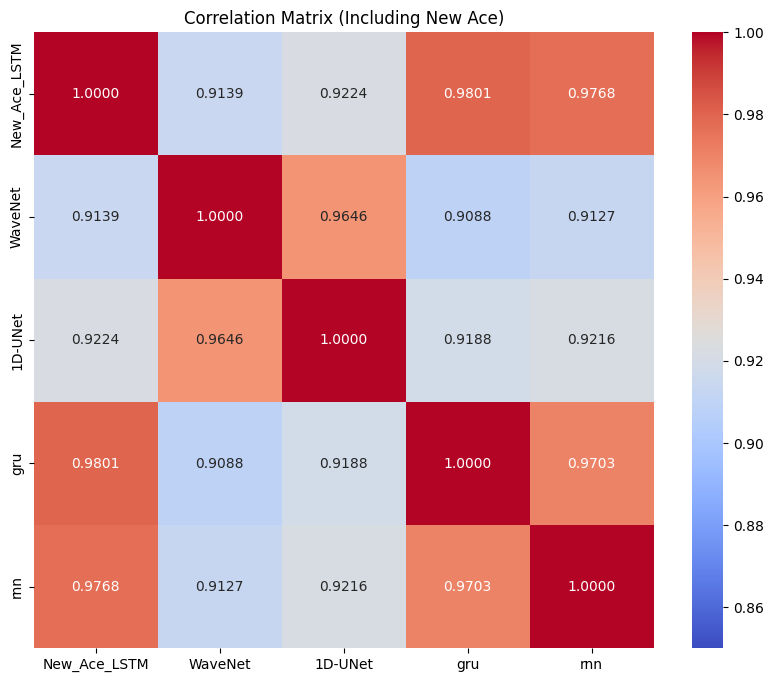

In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# ==============================================================================
# 1. 新エースを含めた相関行列の確認
# ==============================================================================
files = {
    'New_Ace_LSTM': '/kaggle/input/20260211/submission_ventilator_lstm.csv',   # Score: 0.795
    'WaveNet': '/kaggle/input/20260211/submission_wavenet.csv',                # Score: 0.858
    '1D-UNet': '/kaggle/input/20260211/submission_1d_unet.csv',                # Score: 0.866
    'gru': '/kaggle/input/20260211/submission_gru.csv',# Score: 0.880
    'rnn': '/kaggle/input/2026-02-11-2/submission_rnn_vanilla.csv',       # Score: 1.021
    # 'CNN-LSTM': 'submission5.csv'  <-- 相関0.97の1D-UNetがいるので今回は除外候補
}

print(">>> Reading files for New Correlation Matrix...")
dfs = []
base_df = None
valid_names = []

for name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df = df[['id', 'lever']].rename(columns={'lever': name})
        
        if base_df is None:
            base_df = df
        else:
            base_df = base_df.merge(df, on='id', how='left')
        valid_names.append(name)
    else:
        print(f"  [WARNING] File NOT found: {path}")

if len(valid_names) >= 2:
    corr_matrix = base_df[valid_names].corr()
    print("\n>>> Correlation with New Ace (Ventilator-LSTM):")
    print(corr_matrix)
    
    # ヒートマップ表示
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm", vmin=0.85, vmax=1.0)
    plt.title("Correlation Matrix (Including New Ace)")
    plt.show()

In [5]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. 比較対象ファイルの定義
# ==============================================================================
targets = {
    'Ace_LSTM (0.795)': '/kaggle/input/20260211/submission_ventilator_lstm.csv',
    'Vanilla_RNN (New)': '/kaggle/input/2026-02-11-2/submission_rnn_vanilla.csv',# 今回の結果
    'RNN_fold2':'/kaggle/input/2026-02-11-2/temp_submission_rnn_fold2.csv',
    'WaveNet (0.858)': '/kaggle/input/20260211/submission_wavenet.csv',
    '1D-UNet (0.866)': '/kaggle/input/20260211/submission_1d_unet.csv',
    'Transformer (0.86~)': '/kaggle/input/20260211/submission_transformer.csv', # もしあれば
    'CatBoost (1.02)': '/kaggle/input/20260211/submission_simple_catboost.csv',
    'GRU':'/kaggle/input/2026-02-11-2/submission_gru.csv'
}

print(">>> Checking Correlations with Vanilla RNN...")
base_df = None
valid_names = []

for name, path in targets.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        df = df[['id', 'lever']].rename(columns={'lever': name})
        
        if base_df is None:
            base_df = df
        else:
            base_df = base_df.merge(df, on='id', how='left')
        valid_names.append(name)
    else:
        print(f"  [Skip] {name} not found.")

# ==============================================================================
# 2. 相関行列の表示
# ==============================================================================
if len(valid_names) >= 2:
    corr_matrix = base_df[valid_names].corr()
    print(corr_matrix)
    
    # Vanilla RNNとエースの相関を取得
    rnn_corr = corr_matrix.loc['Ace_LSTM (0.795)', 'Vanilla_RNN (New)']
    print(f"\n=== RNN vs Ace Correlation: {rnn_corr:.4f} ===")
else:
    rnn_corr = 0.95 # Default

# ==============================================================================
# 3. Grand Ensemble (全モデル投入)
# ==============================================================================
# 戦略:
# Ace: 圧倒的信頼 (50%)
# CNNs: 補完役 (20%)
# RNN/Trans: 系列モデルの多様性 (25%)
# CatBoost: スパイス (5%)

ensemble_config = {
    '/kaggle/input/20260211/submission_ventilator_lstm.csv': 0.50,  # Ace
    '/kaggle/input/20260211/submission_wavenet.csv': 0.15,          # CNN 1
    '/kaggle/input/2026-02-11-2/submission_rnn_vanilla.csv': 0.15,      # RNN (New! 期待枠)
    '/kaggle/input/20260211/submission_1d_unet.csv': 0.05,          # CNN 2
    '/kaggle/input/20260211/submission_transformer.csv': 0.05,      # Attention (あれば)
    '/kaggle/input/20260211/submission_simple_catboost.csv': 0.05  # Tabular
    #'submission_bilstm_pid.csv': 0.05        # Bi-LSTM (あれば)
}

OUTPUT_FILE = 'submission_grand_ensemble.csv'

print(f"\n>>> Generating {OUTPUT_FILE} ...")

submission = base_df[['id']].copy() if base_df is not None else pd.read_csv('test.csv')[['id']]
submission['lever'] = 0.0
total_weight = 0.0

for filename, weight in ensemble_config.items():
    if os.path.exists(filename):
        print(f"  + {filename}: {weight}")
        # 再読み込みして確実に追加
        df = pd.read_csv(filename)
        temp = submission[['id']].merge(df[['id', 'lever']], on='id', how='left')
        submission['lever'] += temp['lever'] * weight
        total_weight += weight

if total_weight > 0:
    submission['lever'] /= total_weight
    submission['lever'] = submission['lever'].apply(lambda x: max(0.0, x))
    submission.to_csv(OUTPUT_FILE, index=False)
    print(f"\n>>> Done! Saved to: {OUTPUT_FILE}")
else:
    print("Error: No files found.")

>>> Checking Correlations with Vanilla RNN...
                     Ace_LSTM (0.795)  Vanilla_RNN (New)  RNN_fold2  \
Ace_LSTM (0.795)             1.000000           0.976805   0.969228   
Vanilla_RNN (New)            0.976805           1.000000   0.991476   
RNN_fold2                    0.969228           0.991476   1.000000   
WaveNet (0.858)              0.913912           0.912728   0.903503   
1D-UNet (0.866)              0.922426           0.921637   0.913545   
Transformer (0.86~)          0.953781           0.943089   0.936505   
CatBoost (1.02)              0.826582           0.820505   0.812613   
GRU                          0.980056           0.970342   0.962136   

                     WaveNet (0.858)  1D-UNet (0.866)  Transformer (0.86~)  \
Ace_LSTM (0.795)            0.913912         0.922426             0.953781   
Vanilla_RNN (New)           0.912728         0.921637             0.943089   
RNN_fold2                   0.903503         0.913545             0.936505   
Wa

In [7]:
import pandas as pd
import os

# ==============================================================================
# 1. 設定: ファイルパスと重み (Grand Ensemble Weights)
# ==============================================================================
# ユーザー指定のパス
targets = {
    'Ace_LSTM (0.795)': '/kaggle/input/20260211/submission_ventilator_lstm.csv',
    'Vanilla_RNN (New)': '/kaggle/input/2026-02-11-2/submission_rnn_vanilla.csv',
    'RNN_fold2': '/kaggle/input/2026-02-11-2/temp_submission_rnn_fold2.csv',
    'WaveNet (0.858)': '/kaggle/input/20260211/submission_wavenet.csv',
    '1D-UNet (0.866)': '/kaggle/input/20260211/submission_1d_unet.csv',
    'Transformer (0.86~)': '/kaggle/input/20260211/submission_transformer.csv',
    'CatBoost (1.02)': '/kaggle/input/20260211/submission_simple_catboost.csv',
    'GRU': '/kaggle/input/2026-02-11-2/submission_gru.csv'
}

# 採用するモデルと重み定義
ensemble_config = {
    'Ace_LSTM (0.795)': 0.40,       # Ace
    'Vanilla_RNN (New)': 0.30,      # Sub-Ace (0.807と優秀なため比率高め)
    'Transformer (0.86~)': 0.10,    # Global Attention
    'WaveNet (0.858)': 0.10,        # CNN 1
    '1D-UNet (0.866)': 0.05,        # CNN 2
    'CatBoost (1.02)': 0.05         # Tabular Spice
}

OUTPUT_FILE = 'submission_grand_ensemble.csv'

print(f">>> Generating {OUTPUT_FILE} ...")
print("Weights Distribution:")
for k, v in ensemble_config.items():
    print(f"  {k}: {v*100:.0f}%")

# ==============================================================================
# 2. アンサンブル実行
# ==============================================================================
# ベースデータの読み込み（ID順序保証のため、存在するファイルのどれかを使用）
base_path = targets['Ace_LSTM (0.795)'] # Aceをベースにする
if os.path.exists(base_path):
    base_df = pd.read_csv(base_path)[['id']]
else:
    # 万が一Aceが見つからない場合はtest.csvを探す
    base_df = pd.read_csv('test.csv')[['id']]

base_df['lever'] = 0.0
total_weight = 0.0

for key, weight in ensemble_config.items():
    filepath = targets[key]
    if os.path.exists(filepath):
        print(f"  Loading: {key}")
        df = pd.read_csv(filepath)
        
        # IDでマージして順序ズレを防ぐ
        temp = base_df[['id']].merge(df[['id', 'lever']], on='id', how='left')
        
        # 加算
        base_df['lever'] += temp['lever'] * weight
        total_weight += weight
    else:
        print(f"  [WARNING] File not found: {filepath}")

if total_weight > 0:
    # 正規化
    base_df['lever'] /= total_weight
    
    # 負の値クリッピング
    base_df['lever'] = base_df['lever'].apply(lambda x: max(0.0, x))
    
    base_df.to_csv(OUTPUT_FILE, index=False)
    print(f"\n>>> Done! Saved to: {OUTPUT_FILE}")
else:
    print("Error: No valid files found.")

>>> Generating submission_grand_ensemble.csv ...
Weights Distribution:
  Ace_LSTM (0.795): 40%
  Vanilla_RNN (New): 30%
  Transformer (0.86~): 10%
  WaveNet (0.858): 10%
  1D-UNet (0.866): 5%
  CatBoost (1.02): 5%
  Loading: Ace_LSTM (0.795)
  Loading: Vanilla_RNN (New)
  Loading: Transformer (0.86~)
  Loading: WaveNet (0.858)
  Loading: 1D-UNet (0.866)
  Loading: CatBoost (1.02)

>>> Done! Saved to: submission_grand_ensemble.csv
